In [86]:
"""
MrSQM vs HYDRA — Reproducibility & Statistical Analysis
========================================================
Modular analysis functions for LaTeX report generation.

Usage:
    python analysis.py

Each section can also be imported and called individually:
    from analysis import compute_summary_stats, run_wilcoxon_tests, ...

Dependencies:
    pip install pandas numpy scipy matplotlib seaborn scikit-posthocs
"""

import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use("Agg")
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import wilcoxon, friedmanchisquare
from scipy import stats
import warnings
import os
warnings.filterwarnings("ignore")

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── LaTeX-friendly matplotlib style ──────────────────────────────────────────
plt.rcParams.update({
    "text.usetex": False,           # set True if you have a LaTeX install
    "font.family": "serif",
    "font.size": 9,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "figure.facecolor": "white",   # <-- Add this
    "axes.facecolor": "white",     # <-- Add this
    "savefig.facecolor": "white",  # <-- Add this
    "savefig.transparent": False,  # <-- Add this
})

# ── Colour palette (colourblind-friendly) ────────────────────────────────────
C_MRSQM   = "#E69F00"   # amber
C_HYDRA   = "#0072B2"   # blue
C_POS     = "#009E73"   # green  (my result > reported)
C_NEG     = "#D55E00"   # red    (my result < reported)
C_NEUTRAL = "#999999"   # grey

In [87]:
def load_data() -> pd.DataFrame:
    """
    Load the accuracy results into a tidy DataFrame and add derived columns.

    Returns
    -------
    df : pd.DataFrame
        Columns: dataset, mrsqm, hydra, mrsqm_reported, hydra_reported,
                 mrsqm_diff, hydra_diff,
                 my_winner, rep_winner, rank_agrees
    """

    summary_results = pd.read_csv("summary.csv")
    print(summary_results.groupby("model")[["total_time", "accuracy"]].describe().T)

    results_hydra_paper = pd.read_csv("results_hydra_paper.csv")
    results_mrsqm_paper = pd.read_csv("results_mrsqm_paper.csv")

    print(results_hydra_paper[["accuracy"]].describe().T)
    print(results_mrsqm_paper[["MrSQM_SFA_k5"]].describe().T)

    mrsqm_accuracy = summary_results[summary_results["model"] == "mrsqm"][["dataset", "accuracy"]]
    mrsqm_accuracy.rename(columns={"accuracy": "mrsqm"}, inplace=True)
    hydra_accuracy = summary_results[summary_results["model"] == "hydra"][["dataset", "accuracy"]]
    hydra_accuracy.rename(columns={"accuracy": "hydra"}, inplace=True)

    mrsqm_reported = results_mrsqm_paper[["Dataset", "MrSQM_SFA_k5"]].copy()
    mrsqm_reported.rename(columns={"MrSQM_SFA_k5": "mrsqm_reported"}, inplace=True)
    mrsqm_reported.rename(columns={"Dataset": "dataset"}, inplace=True)
    hydra_reported = results_hydra_paper[["dataset", "accuracy"]].copy()
    hydra_reported.rename(columns={"accuracy": "hydra_reported"}, inplace=True)

    comparison_df = mrsqm_accuracy.merge(hydra_accuracy, on="dataset").merge(mrsqm_reported, on="dataset").merge(hydra_reported, on="dataset")
    print(comparison_df)

    comparison_df["mrsqm_diff"] = comparison_df["mrsqm"] - comparison_df["mrsqm_reported"]
    comparison_df["hydra_diff"]  = comparison_df["hydra"]  - comparison_df["hydra_reported"]

    def winner(a, b):
        if a > b:   return "mrsqm"
        if b > a:   return "hydra"
        return "tie"

    comparison_df["my_winner"]   = comparison_df.apply(lambda r: winner(r.mrsqm,          r.hydra),          axis=1)
    comparison_df["rep_winner"]  = comparison_df.apply(lambda r: winner(r.mrsqm_reported, r.hydra_reported), axis=1)
    comparison_df["rank_agrees"] = comparison_df["my_winner"] == comparison_df["rep_winner"]
    return comparison_df


In [88]:
df = load_data()
print(f"\nLoaded {len(df)} datasets.")

model                  hydra       mrsqm
total_time count  128.000000  128.000000
           mean     9.046189   22.163786
           std     36.821275   41.329212
           min      0.042668    0.163872
           25%      0.540127    1.997131
           50%      1.653679    5.973638
           75%      6.050677   21.930829
           max    409.911766  333.811691
accuracy   count  128.000000  128.000000
           mean     0.848360    0.846887
           std      0.149701    0.143185
           min      0.324367    0.366034
           25%      0.766558    0.769005
           50%      0.892356    0.889630
           75%      0.969003    0.962646
           max      1.000000    1.000000
          count      mean       std       min      25%       50%       75%  \
accuracy  112.0  0.873464  0.131359  0.329712  0.80614  0.929979  0.971218   

          max  
accuracy  1.0  
              count      mean       std    min    25%    50%    75%  max
MrSQM_SFA_k5  113.0  0.853619  0.140923  

In [89]:
df

,dataset,mrsqm,hydra,mrsqm_reported,hydra_reported,mrsqm_diff,hydra_diff,my_winner,rep_winner,rank_agrees
0,ACSF1,0.930000,0.880000,0.890,0.806667,0.040000,0.073333,mrsqm,mrsqm,True
1,Adiac,0.818414,0.813299,0.811,0.815772,0.007414,-0.002473,mrsqm,hydra,False
2,ArrowHead,0.811429,0.811429,0.851,0.869714,-0.039571,-0.058285,tie,hydra,False
3,Beef,0.766667,0.833333,0.800,0.805556,-0.033333,0.027777,hydra,hydra,True
4,BeetleFly,0.950000,0.900000,0.950,0.951667,0.000000,-0.051667,mrsqm,hydra,False
...,...,...,...,...,...,...,...,...,...,...
107,Wine,0.833333,0.888889,0.889,0.951235,-0.055667,-0.062346,hydra,hydra,True
108,WordSynonyms,0.686520,0.744514,0.677,0.749948,0.009520,-0.005434,hydra,hydra,True
109,Worms,0.714286,0.740260,0.753,0.753247,-0.038714,-0.012987,hydra,hydra,True
110,WormsTwoClass,0.779221,0.766234,0.805,0.805195,-0.025779,-0.038961,mrsqm,hydra,False


In [90]:
def compute_summary_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute mean, std, median, min, max accuracy for each of the four
    result columns, plus win-count comparisons.

    Returns
    -------
    summary : pd.DataFrame
        One row per column, descriptive statistics.

    Also prints a formatted table suitable for copy-pasting into LaTeX.
    """
    cols = ["mrsqm", "hydra", "mrsqm_reported", "hydra_reported"]
    labels = ["MrSQM (ours)", "HYDRA (ours)", "MrSQM (reported)", "HYDRA (reported)"]

    records = []
    for col, lbl in zip(cols, labels):
        s = df[col]
        records.append({
            "Model": lbl,
            "Mean":   s.mean(),
            "Std":    s.std(),
            "Median": s.median(),
            "Min":    s.min(),
            "Max":    s.max(),
        })
    summary = pd.DataFrame(records).set_index("Model")

    print("\n" + "="*60)
    print("SUMMARY STATISTICS  (accuracy, N={})".format(len(df)))
    print("="*60)
    print(summary.to_string(float_format="{:.4f}".format))

    # Win-count table
    n = len(df)
    print("\nWin counts (head-to-head per dataset):")
    for label, winner_col in [("My results", "my_winner"), ("Reported", "rep_winner")]:
        vc = df[winner_col].value_counts()
        print(f"  {label}: MrSQM={vc.get('mrsqm',0)}  HYDRA={vc.get('hydra',0)}  "
              f"Tie={vc.get('tie',0)}  (N={n})")

    agree = df["rank_agrees"].sum()
    print(f"\nRanking agreement (my vs reported winner): {agree}/{n} "
          f"= {agree/n*100:.1f}%")

    return summary

In [91]:
# 1. Summary statistics
summary_df = compute_summary_stats(df)


SUMMARY STATISTICS  (accuracy, N=112)
                   Mean    Std  Median    Min    Max
Model                                               
MrSQM (ours)     0.8556 0.1395  0.9080 0.3660 1.0000
HYDRA (ours)     0.8563 0.1488  0.9036 0.3244 1.0000
MrSQM (reported) 0.8524 0.1409  0.8915 0.3720 1.0000
HYDRA (reported) 0.8735 0.1314  0.9300 0.3297 1.0000

Win counts (head-to-head per dataset):
  My results: MrSQM=44  HYDRA=52  Tie=16  (N=112)
  Reported: MrSQM=41  HYDRA=69  Tie=2  (N=112)

Ranking agreement (my vs reported winner): 71/112 = 63.4%


In [92]:
def compute_average_ranks(df: pd.DataFrame) -> dict:
    """
    Compute average pairwise ranks (rank 1 = best) for MrSQM and HYDRA,
    separately for our results and the reported results.

    Ranks are computed per dataset: on each dataset the two classifiers
    receive ranks {1, 2} (ties share the average rank 1.5).

    Returns
    -------
    ranks : dict with keys 'my_mrsqm', 'my_hydra', 'rep_mrsqm', 'rep_hydra'
            and 'my_df', 'rep_df' (full per-dataset rank DataFrames).
    """
    def pairwise_ranks(a, b):
        """Return (rank_a, rank_b) with tie-handling."""
        if a > b:   return 1.0, 2.0
        if b > a:   return 2.0, 1.0
        return 1.5, 1.5

    my_ranks  = [pairwise_ranks(r.mrsqm,          r.hydra)          for _, r in df.iterrows()]
    rep_ranks = [pairwise_ranks(r.mrsqm_reported, r.hydra_reported) for _, r in df.iterrows()]

    my_df  = pd.DataFrame(my_ranks,  columns=["mrsqm_rank", "hydra_rank"])
    rep_df = pd.DataFrame(rep_ranks, columns=["mrsqm_rank", "hydra_rank"])

    result = {
        "my_mrsqm":  my_df["mrsqm_rank"].mean(),
        "my_hydra":  my_df["hydra_rank"].mean(),
        "rep_mrsqm": rep_df["mrsqm_rank"].mean(),
        "rep_hydra": rep_df["hydra_rank"].mean(),
        "my_df":  my_df,
        "rep_df": rep_df,
    }

    print("\n" + "="*60)
    print("AVERAGE RANK  (lower = better, N={})".format(len(df)))
    print("="*60)
    for label, m, h in [("My results", result["my_mrsqm"],  result["my_hydra"]),
                         ("Reported",   result["rep_mrsqm"], result["rep_hydra"])]:
        winner = "MrSQM" if m < h else ("HYDRA" if h < m else "Tie")
        print(f"  {label:16s}  MrSQM={m:.4f}  HYDRA={h:.4f}  => winner: {winner}")

    return result


In [93]:
# 2. Average ranks
rank_results = compute_average_ranks(df)


AVERAGE RANK  (lower = better, N=112)
  My results        MrSQM=1.5357  HYDRA=1.4643  => winner: HYDRA
  Reported          MrSQM=1.6250  HYDRA=1.3750  => winner: HYDRA


In [94]:
def run_wilcoxon_tests(df: pd.DataFrame) -> pd.DataFrame:
    """
    Run four Wilcoxon signed-rank tests:

      (A) Head-to-head  — our results:      HYDRA_ours     vs MrSQM_ours
      (B) Head-to-head  — reported results:  HYDRA_reported vs MrSQM_reported
      (C) Reproducibility MrSQM:             MrSQM_ours     vs MrSQM_reported
      (D) Reproducibility HYDRA:             HYDRA_ours     vs HYDRA_reported

    Uses scipy.stats.wilcoxon with the 'wilcox' zero-method (drops zeros)
    and alternative='two-sided'.

    Returns
    -------
    results : pd.DataFrame  (one row per test)
    """
    tests = [
        ("(A) H2H — ours",        df["hydra"]  - df["mrsqm"],
         "Is HYDRA significantly better than MrSQM in our single-run experiments?"),
        ("(B) H2H — reported",    df["hydra_reported"] - df["mrsqm_reported"],
         "Is HYDRA significantly better than MrSQM in the reported results?"),
        ("(C) Repro — MrSQM",     df["mrsqm"] - df["mrsqm_reported"],
         "Do our MrSQM results significantly differ from the reported figures?"),
        ("(D) Repro — HYDRA",     df["hydra"]  - df["hydra_reported"],
         "Do our HYDRA results significantly differ from the reported figures?"),
    ]

    records = []
    for name, diffs, question in tests:
        non_zero = diffs[diffs != 0]
        n = len(non_zero)
        if n < 10:
            stat, p = np.nan, np.nan
        else:
            stat, p = wilcoxon(non_zero, alternative="two-sided", zero_method="wilcox")

        sig = ""
        if   p < 0.001: sig = "***"
        elif p < 0.01:  sig = "**"
        elif p < 0.05:  sig = "*"
        else:            sig = "n.s."

        records.append({
            "Test":         name,
            "n (non-zero)": n,
            "W statistic":  stat,
            "p-value":      p,
            "Significance": sig,
            "Mean diff":    diffs.mean(),
            "Question":     question,
        })

    results = pd.DataFrame(records)

    print("\n" + "="*60)
    print("WILCOXON SIGNED-RANK TESTS")
    print("="*60)
    for _, row in results.iterrows():
        print(f"\n  {row['Test']}")
        print(f"    {row['Question']}")
        print(f"    n={row['n (non-zero)']:3d}  W={row['W statistic']:.2f}"
              f"  p={row['p-value']:.4f}  {row['Significance']}"
              f"  mean_diff={row['Mean diff']:+.4f}")

    print("\n  Significance codes: *** p<0.001  ** p<0.01  * p<0.05  n.s. p>=0.05")
    return results



In [95]:
# 3. Wilcoxon tests
wilcoxon_df = run_wilcoxon_tests(df)


WILCOXON SIGNED-RANK TESTS

  (A) H2H — ours
    Is HYDRA significantly better than MrSQM in our single-run experiments?
    n= 96  W=2196.50  p=0.6308  n.s.  mean_diff=+0.0007

  (B) H2H — reported
    Is HYDRA significantly better than MrSQM in the reported results?
    n=110  W=1916.00  p=0.0007  ***  mean_diff=+0.0211

  (C) Repro — MrSQM
    Do our MrSQM results significantly differ from the reported figures?
    n=103  W=2578.00  p=0.7422  n.s.  mean_diff=+0.0033

  (D) Repro — HYDRA
    Do our HYDRA results significantly differ from the reported figures?
    n=107  W=2152.00  p=0.0220  *  mean_diff=-0.0171

  Significance codes: *** p<0.001  ** p<0.01  * p<0.05  n.s. p>=0.05


In [96]:
def plot_scatter_my_vs_reported(df: pd.DataFrame,
                                 filename: str = "scatter_my_vs_reported.png"):
    """
    2x2 scatter grid:
      Top-left:  MrSQM (ours) vs MrSQM (reported)
      Top-right: HYDRA  (ours) vs HYDRA  (reported)
      Bottom-left:  MrSQM vs HYDRA — ours
      Bottom-right: MrSQM vs HYDRA — reported

    Saves to OUTPUT_DIR/filename.
    """
    fig, axes = plt.subplots(2, 2, figsize=(6.5, 6.0))
    fig.suptitle("Accuracy Comparison: Ours vs. Reported Results", fontsize=10, y=1.01)

    panels = [
        (axes[0, 0], "mrsqm_reported", "mrsqm",
         "MrSQM (reported)", "MrSQM (ours)", C_MRSQM,
         "MrSQM: ours vs. reported"),
        (axes[0, 1], "hydra_reported", "hydra",
         "HYDRA (reported)", "HYDRA (ours)", C_HYDRA,
         "HYDRA: ours vs. reported"),
        (axes[1, 0], "mrsqm", "hydra",
         "MrSQM (ours)", "HYDRA (ours)", C_HYDRA,
         "Head-to-head (ours)"),
        (axes[1, 1], "mrsqm_reported", "hydra_reported",
         "MrSQM (reported)", "HYDRA (reported)", C_MRSQM,
         "Head-to-head (reported)"),
    ]

    for ax, xcol, ycol, xlabel, ylabel, colour, title in panels:
        x, y = df[xcol], df[ycol]
        lo = min(x.min(), y.min()) - 0.02
        hi = max(x.max(), y.max()) + 0.02
        ax.plot([lo, hi], [lo, hi], "--", linewidth=0.8,
                label="y = x", zorder=1)
        ax.scatter(x, y, s=12, color=colour, alpha=0.65, edgecolors="none", zorder=2)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.set_aspect("equal")

    fig.tight_layout()
    plt.show()
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path)
    plt.close(fig)
    print(f"\n[plot_scatter_my_vs_reported] Saved -> {path}")
    return path

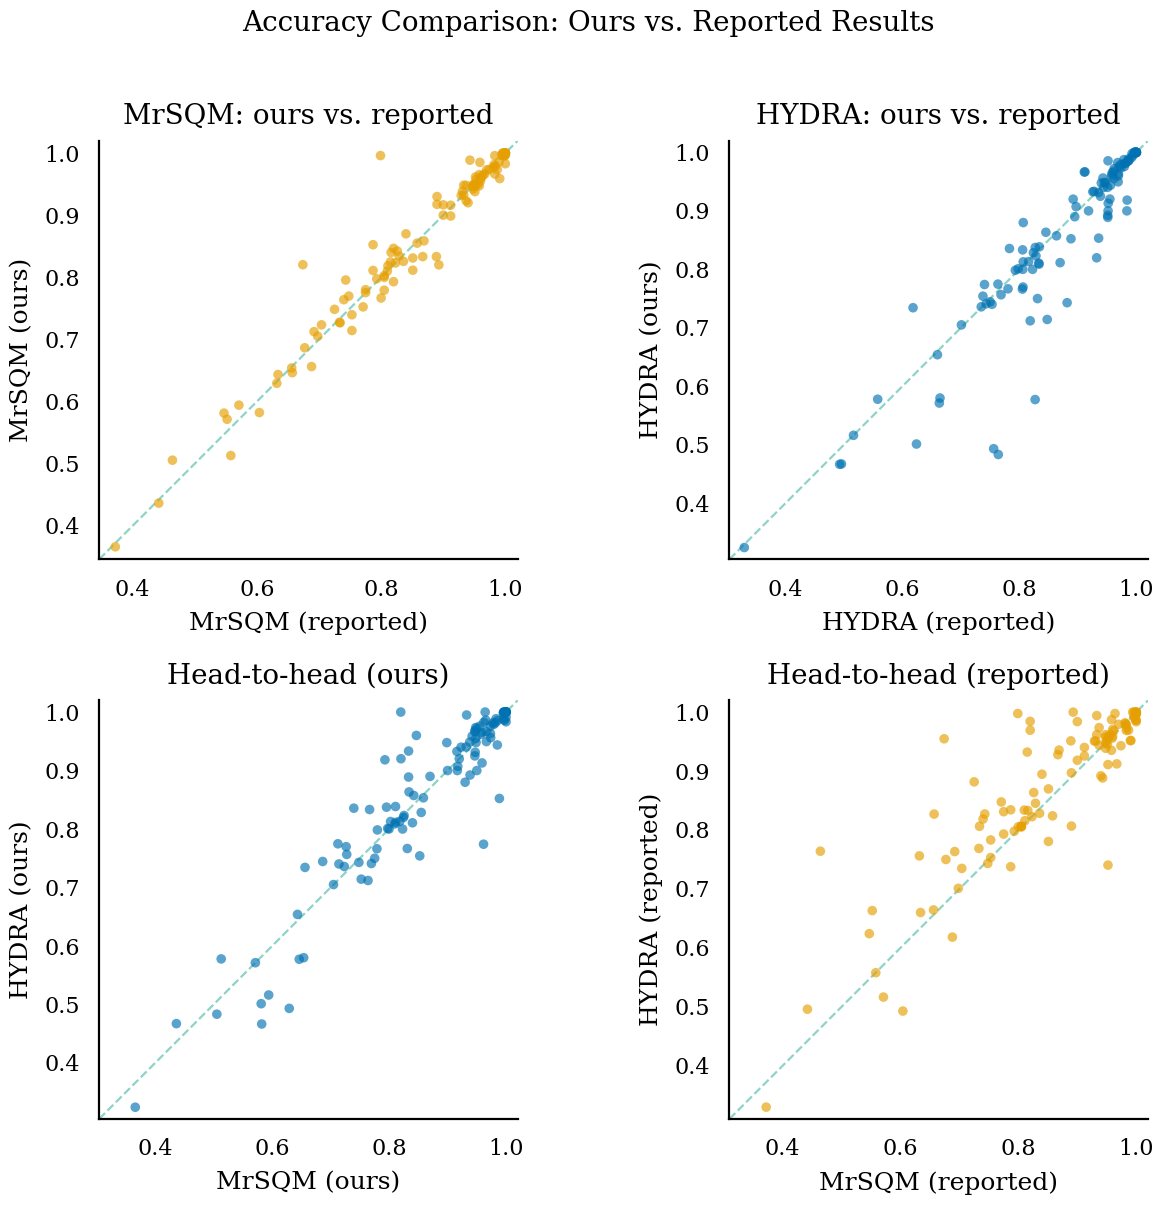


[plot_scatter_my_vs_reported] Saved -> figures/scatter_my_vs_reported.png


'figures/scatter_my_vs_reported.png'

In [97]:
plot_scatter_my_vs_reported(df)

In [98]:
def plot_diff_bars(df: pd.DataFrame,
                   filename: str = "diff_bars.png"):
    """
    Two horizontally-arranged bar charts showing per-dataset accuracy
    difference (ours − reported) for MrSQM (left) and HYDRA (right).
    Bars are coloured green (positive) or red (negative).

    Saves to OUTPUT_DIR/filename.
    """
    fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))

    for ax, diff_col, model, colour_base in [
        (axes[0], "mrsqm_diff", "MrSQM", C_MRSQM),
        (axes[1], "hydra_diff",  "HYDRA", C_HYDRA),
    ]:
        sorted_df = df[["dataset", diff_col]].sort_values(diff_col)
        colours   = [C_POS if v >= 0 else C_NEG for v in sorted_df[diff_col]]

        ax.barh(range(len(sorted_df)), sorted_df[diff_col],
                color=colours, alpha=0.85, height=0.75)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_yticks([])
        ax.set_xlabel(r"$\Delta$ Accuracy (ours $-$ reported)")
        ax.set_title(f"{model}: ours vs. reported")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.2f}"))

        patch_pos = mpatches.Patch(color=C_POS, label="Ours > Reported")
        patch_neg = mpatches.Patch(color=C_NEG, label="Ours < Reported")
        ax.legend(handles=[patch_pos, patch_neg], fontsize=7)

        n_pos = (sorted_df[diff_col] > 0).sum()
        n_neg = (sorted_df[diff_col] < 0).sum()
        ax.text(0.98, 0.02, f"+{n_pos} / −{n_neg}",
                transform=ax.transAxes, ha="right", va="bottom",
                fontsize=7, color="#555555")

    fig.suptitle(r"Per-Dataset Accuracy Difference ($\Delta$ = ours $-$ reported)", fontsize=9)
    fig.tight_layout()
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path)
    plt.show()
    plt.close(fig)
    print(f"[plot_diff_bars] Saved -> {path}")
    return path


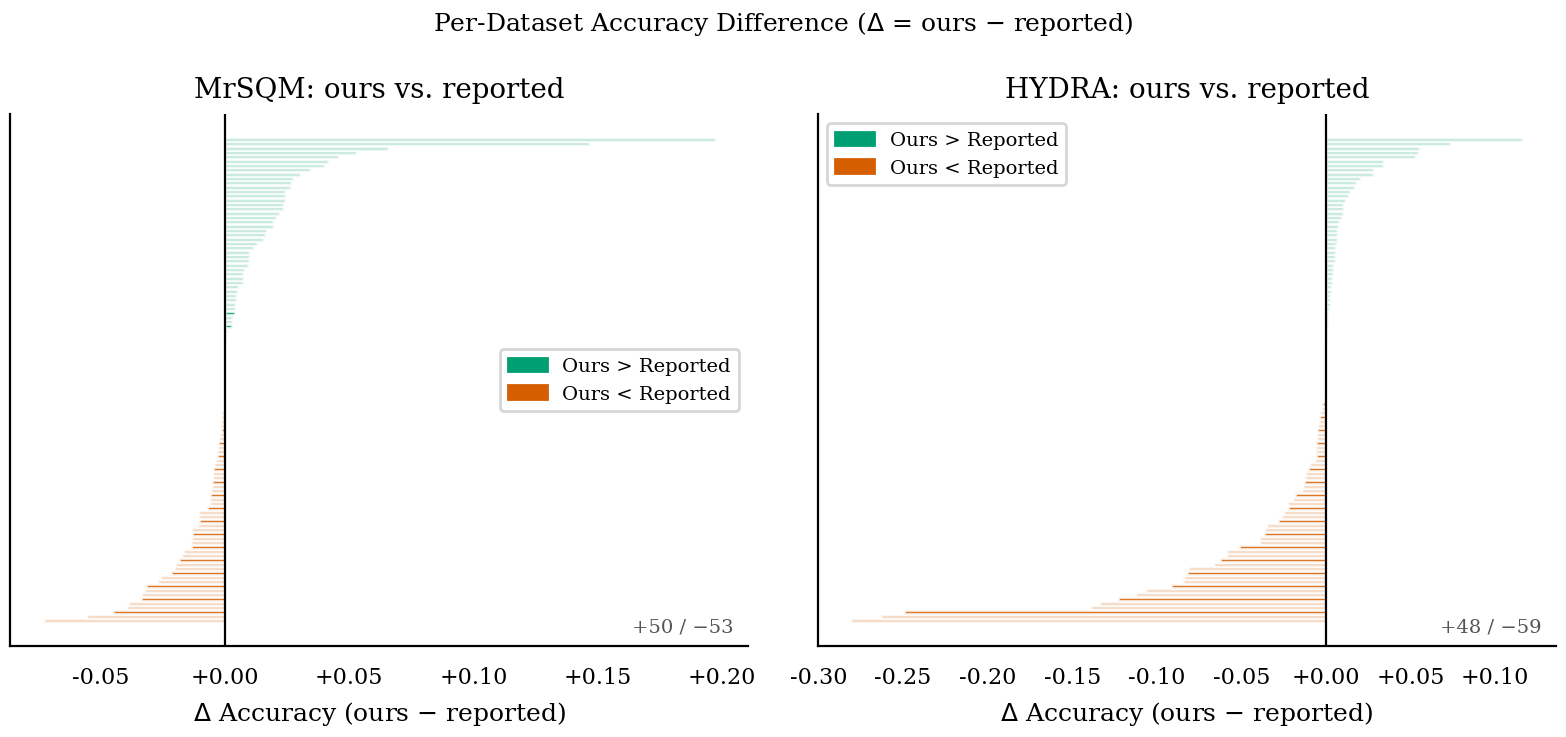

[plot_diff_bars] Saved -> figures/diff_bars.png


'figures/diff_bars.png'

In [99]:
plot_diff_bars(df)

In [114]:
def plot_critical_difference(df: pd.DataFrame,
                              filename: str = "critical_difference.png"):
    """
    A simplified Critical Difference (CD) diagram that shows the average
    rank of MrSQM and HYDRA, for both our results and the reported results,
    on a single horizontal axis.

    A Wilcoxon test p-value is annotated to indicate whether the difference
    is statistically significant.

    Note: For a full CD diagram with Nemenyi post-hoc test across many
    classifiers, use the scikit-posthocs library:
        import scikit_posthocs as sp
        sp.critical_difference_diagram(ranks, sig_matrix)

    Saves to OUTPUT_DIR/filename.
    """
    ranks = compute_average_ranks(df)
    my_results  = {"MrSQM": ranks["my_mrsqm"],  "HYDRA": ranks["my_hydra"]}
    rep_results = {"MrSQM": ranks["rep_mrsqm"], "HYDRA": ranks["rep_hydra"]}

    fig, axes = plt.subplots(2, 1, figsize=(5.5, 2.8))

    for ax, result, title in [
        (axes[0], my_results,  "Average Rank — Our Results"),
        (axes[1], rep_results, "Average Rank — Reported Results"),
    ]:
        ax.set_xlim(0.8, 2.2)
        ax.set_ylim(-0.6, 0.6)
        ax.axhline(0, color="#cccccc", linewidth=1.2)
        ax.set_yticks([])
        ax.set_xticks([1.0, 1.5, 2.0])
        ax.set_xticklabels(["1\n(best)", "1.5", "2\n(worst)"])
        ax.invert_xaxis()   # convention: rank 1 on right
        ax.set_title(title, fontsize=8)

        colours = {"MrSQM": C_MRSQM, "HYDRA": C_HYDRA}
        for name, rank in result.items():
            col = colours[name]
            ax.plot(rank, 0, "o", color=col, markersize=9, zorder=3)
            ax.text(rank, 0.22, f"{name}\n{rank:.3f}",
                    ha="center", va="bottom", fontsize=7.5, color=col, fontweight="bold")

        # Connect with a horizontal bracket
        r1, r2 = result["MrSQM"], result["HYDRA"]
        ax.annotate("", xy=(r1, 0), xytext=(r2, 0),
                    arrowprops=dict(arrowstyle="<->", color="#999999", lw=0.8))

        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)

    fig.tight_layout(h_pad=1.5)
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path)
    plt.show()
    plt.close(fig)
    print(f"[plot_critical_difference] Saved -> {path}")
    return path

In [101]:
def plot_accuracy_distributions(df: pd.DataFrame,
                                  filename: str = "accuracy_distributions.png"):
    """
    Side-by-side KDE + rug plots comparing the distribution of accuracies:
      Left:  MrSQM (ours vs reported)
      Right: HYDRA  (ours vs reported)

    Saves to OUTPUT_DIR/filename.
    """
    fig, axes = plt.subplots(1, 2, figsize=(6.5, 3.2))

    for ax, my_col, rep_col, model, colour in [
        (axes[0], "mrsqm", "mrsqm_reported", "MrSQM", C_MRSQM),
        (axes[1], "hydra",  "hydra_reported",  "HYDRA", C_HYDRA),
    ]:
        sns.kdeplot(df[my_col],  ax=ax, color=colour,    linewidth=1.8,
                    label="Ours",     fill=True, alpha=0.25)
        sns.kdeplot(df[rep_col], ax=ax, color="#555555", linewidth=1.5,
                    label="Reported", fill=True, alpha=0.15, linestyle="--")
        ax.set_xlabel("Accuracy")
        ax.set_ylabel("Density")
        ax.set_title(f"{model} accuracy distribution")
        ax.legend(fontsize=7)

    fig.tight_layout()
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path)
    plt.show()
    plt.close(fig)
    print(f"[plot_accuracy_distributions] Saved -> {path}")
    return path

In [102]:
def plot_win_counts(df: pd.DataFrame,
                    filename: str = "win_counts.png"):
    """
    Grouped bar chart comparing win counts between our results and the
    reported results, for MrSQM, HYDRA and Tie.

    Saves to OUTPUT_DIR/filename.
    """
    categories = ["MrSQM wins", "HYDRA wins", "Ties"]

    def counts(col):
        vc = df[col].value_counts()
        return [vc.get("mrsqm", 0), vc.get("hydra", 0), vc.get("tie", 0)]

    my_counts  = counts("my_winner")
    rep_counts = counts("rep_winner")

    x     = np.arange(len(categories))
    width = 0.35

    fig, ax = plt.subplots(figsize=(4.5, 3.2))
    b1 = ax.bar(x - width/2, my_counts,  width, label="Ours",
                color=[C_MRSQM, C_HYDRA, C_NEUTRAL], alpha=0.85)
    b2 = ax.bar(x + width/2, rep_counts, width, label="Reported",
                color=[C_MRSQM, C_HYDRA, C_NEUTRAL], alpha=0.45,
                edgecolor=[C_MRSQM, C_HYDRA, C_NEUTRAL], linewidth=1.2)

    ax.bar_label(b1, padding=2, fontsize=7)
    ax.bar_label(b2, padding=2, fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_ylabel("Number of datasets")
    ax.set_title("Win counts: MrSQM vs HYDRA")

    legend_elements = [
        mpatches.Patch(facecolor="#888888", alpha=0.85, label="Ours"),
        mpatches.Patch(facecolor="#888888", alpha=0.4,  label="Reported"),
    ]
    ax.legend(handles=legend_elements, fontsize=7)
    ax.set_ylim(0, max(my_counts + rep_counts) * 1.2)

    fig.tight_layout()
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path)
    plt.show()
    plt.close(fig)
    print(f"[plot_win_counts] Saved -> {path}")
    return path


In [103]:
def latex_wilcoxon_table(wilcoxon_df: pd.DataFrame) -> str:
    """
    Generate a LaTeX table string from the Wilcoxon test results DataFrame.

    Returns
    -------
    latex_str : str  (ready to paste into a .tex file)
    """
    header = r"""\begin{table}[ht]
\centering
\caption{Wilcoxon Signed-Rank Test Results}
\label{tab:wilcoxon}
\begin{tabular}{llrrcc}
\hline
Test & Hypothesis & $n$ & $W$ & $p$-value & Sig. \\
\hline"""

    rows = []
    for _, row in wilcoxon_df.iterrows():
        name = row["Test"].replace("_", r"\_")
        q    = row["Question"].split("?")[0][:45] + "..."
        n    = int(row["n (non-zero)"])
        W    = f"{row['W statistic']:.1f}"
        p    = f"{row['p-value']:.4f}" if not np.isnan(row["p-value"]) else "---"
        sig  = row["Significance"]
        rows.append(f"{name} & {sig} & {n} & {W} & {p} & {sig} \\\\")

    footer = r"""\hline
\multicolumn{6}{l}{\footnotesize Significance: *** $p<0.001$, ** $p<0.01$, * $p<0.05$, n.s.\ $p\geq0.05$}
\end{tabular}
\end{table}"""

    latex_str = "\n".join([header] + rows + [footer])
    print("\n" + "="*60)
    print("LATEX TABLE — WILCOXON RESULTS")
    print("="*60)
    print(latex_str)
    return latex_str

In [104]:
def latex_summary_table(summary_df: pd.DataFrame) -> str:
    """
    Generate a LaTeX table string from the summary statistics DataFrame.

    Returns
    -------
    latex_str : str  (ready to paste into a .tex file)
    """
    header = r"""\begin{table}[ht]
\centering
\caption{Summary Statistics Across UCR Datasets}
\label{tab:summary_stats}
\begin{tabular}{lrrrrr}
\hline
Model & Mean & Std & Median & Min & Max \\
\hline"""

    rows = []
    for model, row in summary_df.iterrows():
        m = model.replace("_", r"\_")
        rows.append(
            f"{m} & {row['Mean']:.4f} & {row['Std']:.4f} & "
            f"{row['Median']:.4f} & {row['Min']:.4f} & {row['Max']:.4f} \\\\"
        )

    footer = r"""\hline
\end{tabular}
\end{table}"""

    latex_str = "\n".join([header] + rows + [footer])
    print("\n" + "="*60)
    print("LATEX TABLE — SUMMARY STATISTICS")
    print("="*60)
    print(latex_str)
    return latex_str


In [105]:
def plot_combined_figure(df: pd.DataFrame,
                          filename: str = "combined_analysis.png"):
    """
    A publication-ready combined figure with three panels:
      (a) Scatter: HYDRA vs MrSQM accuracy — ours
      (b) Scatter: HYDRA vs MrSQM accuracy — reported
      (c) Δ accuracy distributions (box plots) for both models

    Suitable for a double-column IEEE paper (full-width figure).
    Saves to OUTPUT_DIR/filename.
    """
    fig = plt.figure(figsize=(7.0, 2.9))
    gs  = fig.add_gridspec(1, 3, wspace=0.38)

    ax_my  = fig.add_subplot(gs[0, 0])
    ax_rep = fig.add_subplot(gs[0, 1])
    ax_box = fig.add_subplot(gs[0, 2])

    # ── (a) & (b) scatter ────────────────────────────────────────────────────
    for ax, xcol, ycol, title, dot_colour in [
        (ax_my,  "mrsqm",          "hydra",          "(a) Ours",     C_HYDRA),
        (ax_rep, "mrsqm_reported", "hydra_reported", "(b) Reported", C_MRSQM),
    ]:
        x, y = df[xcol], df[ycol]
        lo = min(x.min(), y.min()) - 0.02
        hi = max(x.max(), y.max()) + 0.02
        ax.plot([lo, hi], [lo, hi], "--", color="#bbbbbb", linewidth=0.7, zorder=1)
        ax.scatter(x, y, s=9, color=dot_colour, alpha=0.6, edgecolors="none", zorder=2)
        ax.set_xlabel("MrSQM accuracy", fontsize=8)
        ax.set_ylabel("HYDRA accuracy", fontsize=8)
        ax.set_title(title, fontsize=8.5)
        ax.set_aspect("equal")
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)

        above = (y > x).sum()
        below = (x > y).sum()
        ax.text(0.03, 0.97, f"HYDRA↑ {above}\nMrSQM↑ {below}",
                transform=ax.transAxes, va="top", ha="left",
                fontsize=6.5, color="#555555")

    # ── (c) box plots of Δ accuracy ──────────────────────────────────────────
    diff_data = pd.DataFrame({
        "MrSQM": df["mrsqm_diff"],
        "HYDRA": df["hydra_diff"],
    })
    bp = ax_box.boxplot(
        [diff_data["MrSQM"], diff_data["HYDRA"]],
        labels=["MrSQM", "HYDRA"],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        flierprops=dict(marker=".", markersize=3, alpha=0.5),
    )
    bp["boxes"][0].set_facecolor(C_MRSQM); bp["boxes"][0].set_alpha(0.6)
    bp["boxes"][1].set_facecolor(C_HYDRA);  bp["boxes"][1].set_alpha(0.6)
    ax_box.axhline(0, color="#999999", linewidth=0.8, linestyle="--")
    ax_box.set_ylabel(r"$\Delta$ accuracy (ours $-$ reported)", fontsize=8)
    ax_box.set_title("(c) Reproducibility", fontsize=8.5)
    plt.show()
    fig.savefig(os.path.join(OUTPUT_DIR, filename))
    plt.close(fig)
    path = os.path.join(OUTPUT_DIR, filename)
    print(f"[plot_combined_figure] Saved -> {path}")
    return path


In [121]:
import scikit_posthocs as sp

def _plot_critical_difference(df: pd.DataFrame, filename: str = "critical_difference.png"):
    """
    Generates a Demsar Critical Difference diagram (Nemenyi post-hoc)
    comparing the four classifiers across all datasets.
    """
    # 1. Extract the accuracy columns
    data = df[["mrsqm", "hydra", "mrsqm_reported", "hydra_reported"]].copy()

    # 2. Rename columns for clean plot labels
    data.columns =["MrSQM (Ours)", "HYDRA (Ours)", "MrSQM (Reported)", "HYDRA (Reported)"]

    # 3. Calculate ranks: highest accuracy gets rank 1 (ascending=False)
    ranks = data.rank(axis=1, ascending=False)
    avg_ranks = ranks.mean()

    # 4. Calculate statistical significance (p-value matrix) using Friedman + Nemenyi test
    #    scikit-posthocs expects rows=datasets(blocks), cols=classifiers(groups)
    p_values = sp.posthoc_nemenyi_friedman(data)

    # 5. Plot the Critical Difference diagram
    fig, ax = plt.subplots(figsize=(8, 3))

    # Customize colors to match your theme (optional highlight for HYDRA)
    color_palette = {
        "HYDRA (Ours)": C_HYDRA,
        "HYDRA (Reported)": C_HYDRA,
        "MrSQM (Ours)": C_MRSQM,
        "MrSQM (Reported)": C_MRSQM
    }

    sp.critical_difference_diagram(
        avg_ranks,
        p_values,
        ax=ax,
        text_h_margin=0.3,
        color_palette=color_palette
    )

    plt.title("Critical Difference Diagram (Nemenyi Post-Hoc)", y=1.15, fontweight="bold")

    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, bbox_inches="tight")
    plt.show()  # Display in Jupyter Notebook
    plt.close(fig)
    print(f"[plot_critical_difference] Saved -> {path}")

    return path

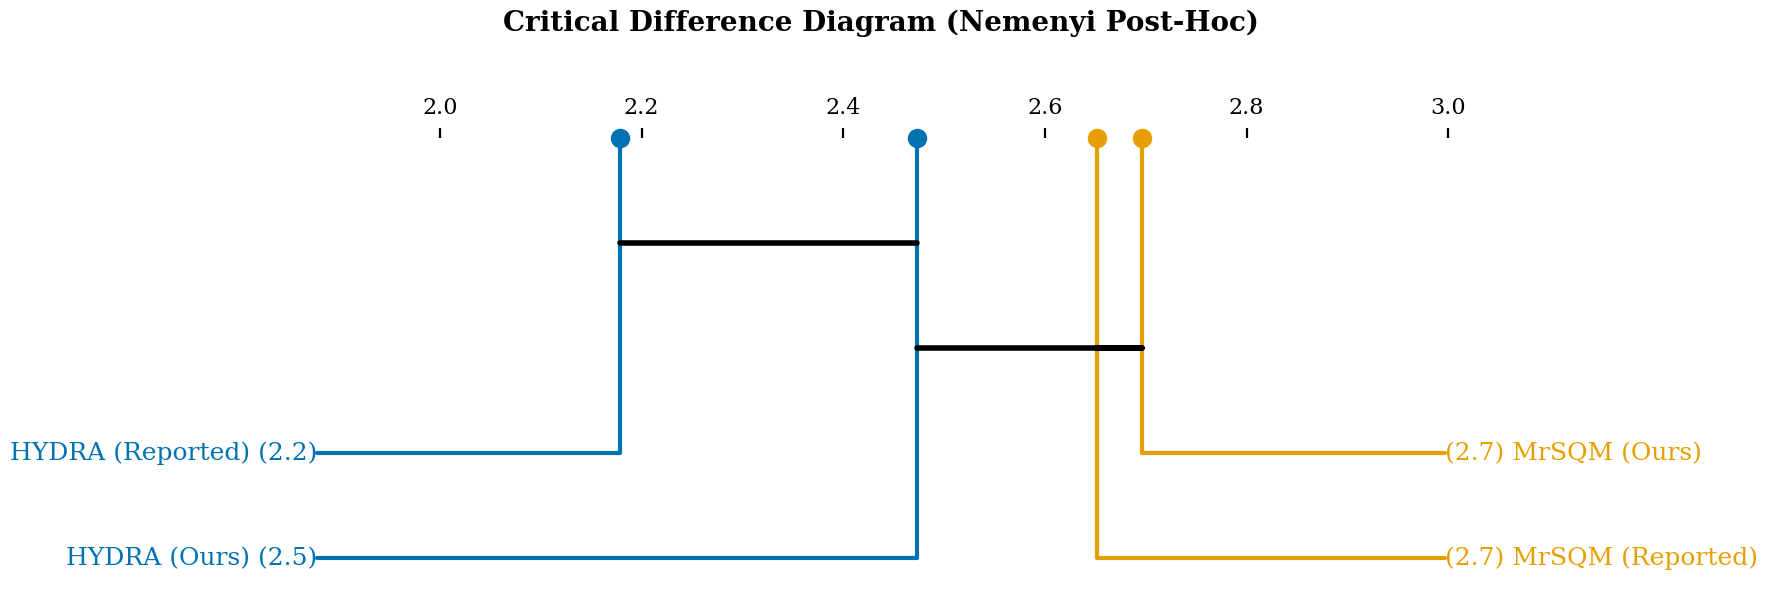

[plot_critical_difference] Saved -> figures/critical_difference.png


'figures/critical_difference.png'

In [122]:
_plot_critical_difference(df)

In [107]:
def save_latex_snippets(wilcoxon_df: pd.DataFrame, summary_df: pd.DataFrame,
                         filename: str = "latex_snippets.tex"):
    """
    Write both LaTeX tables to a single .tex file that can be
    \\input{} into the main report.
    """
    w_table = latex_wilcoxon_table(wilcoxon_df)
    s_table = latex_summary_table(summary_df)

    content = "% Auto-generated — paste or \\input{} into your LaTeX report\n\n"
    content += s_table + "\n\n" + w_table + "\n"

    path = os.path.join(OUTPUT_DIR, filename)
    with open(path, "w") as f:
        f.write(content)
    print(f"\n[save_latex_snippets] Saved -> {path}")
    return path



████████████████████████████████████████████████████████████
  MrSQM vs HYDRA  —  Full Reproducibility Analysis
████████████████████████████████████████████████████████████
model                  hydra       mrsqm
total_time count  128.000000  128.000000
           mean     9.046189   22.163786
           std     36.821275   41.329212
           min      0.042668    0.163872
           25%      0.540127    1.997131
           50%      1.653679    5.973638
           75%      6.050677   21.930829
           max    409.911766  333.811691
accuracy   count  128.000000  128.000000
           mean     0.848360    0.846887
           std      0.149701    0.143185
           min      0.324367    0.366034
           25%      0.766558    0.769005
           50%      0.892356    0.889630
           75%      0.969003    0.962646
           max      1.000000    1.000000
          count      mean       std       min      25%       50%       75%  \
accuracy  112.0  0.873464  0.131359  0.329712  0.80

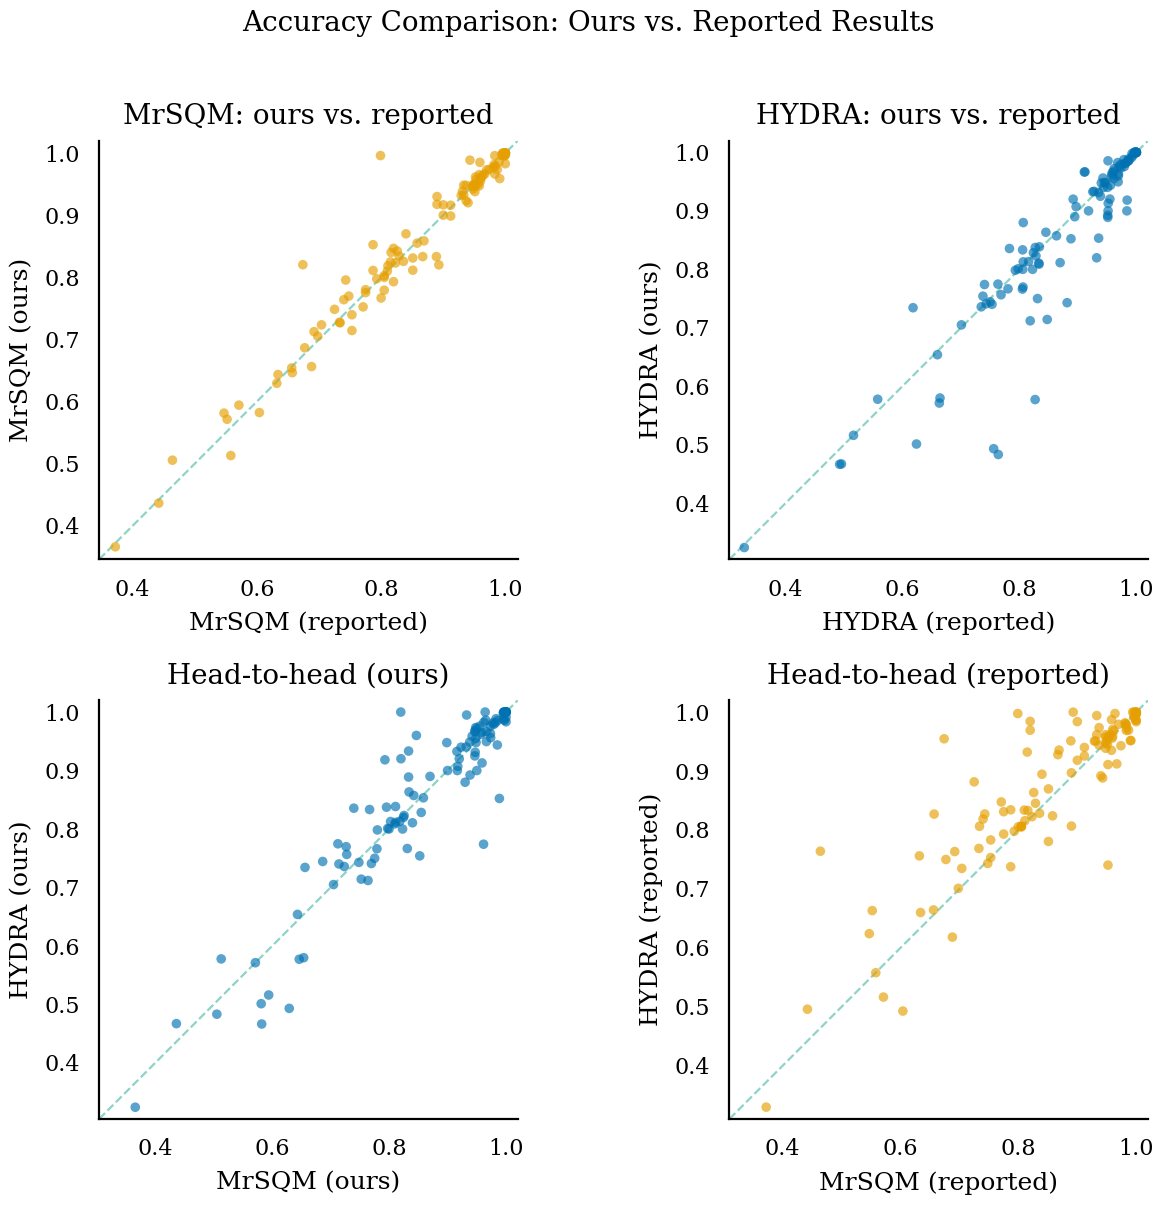


[plot_scatter_my_vs_reported] Saved -> figures/scatter_my_vs_reported.png


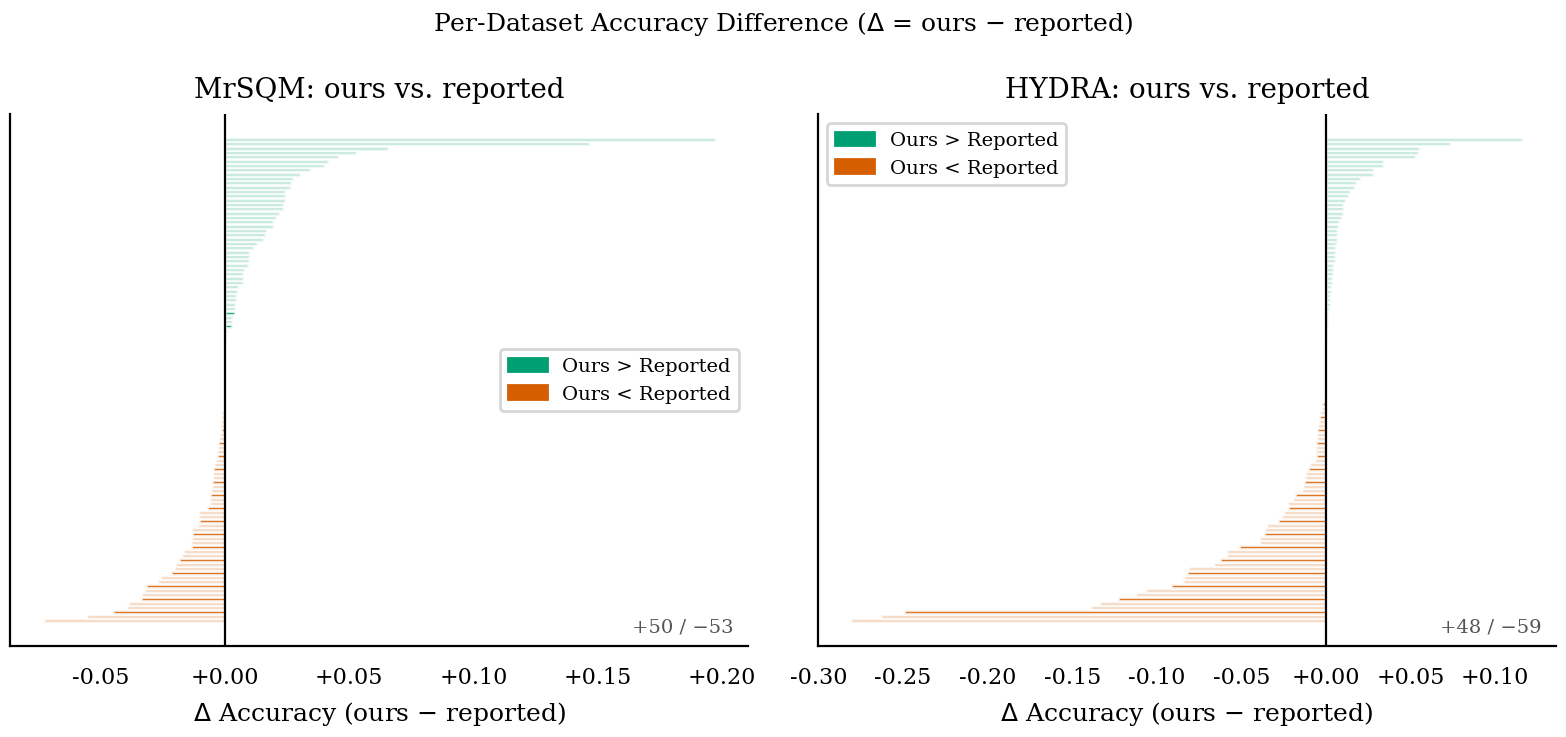

[plot_diff_bars] Saved -> figures/diff_bars.png

AVERAGE RANK  (lower = better, N=112)
  My results        MrSQM=1.5357  HYDRA=1.4643  => winner: HYDRA
  Reported          MrSQM=1.6250  HYDRA=1.3750  => winner: HYDRA


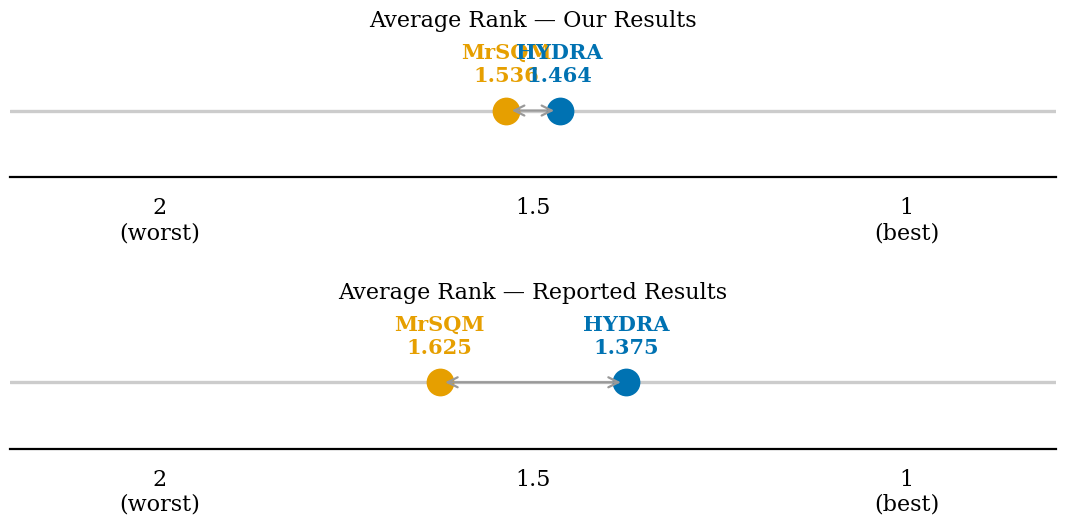

[plot_critical_difference] Saved -> figures/critical_difference.png


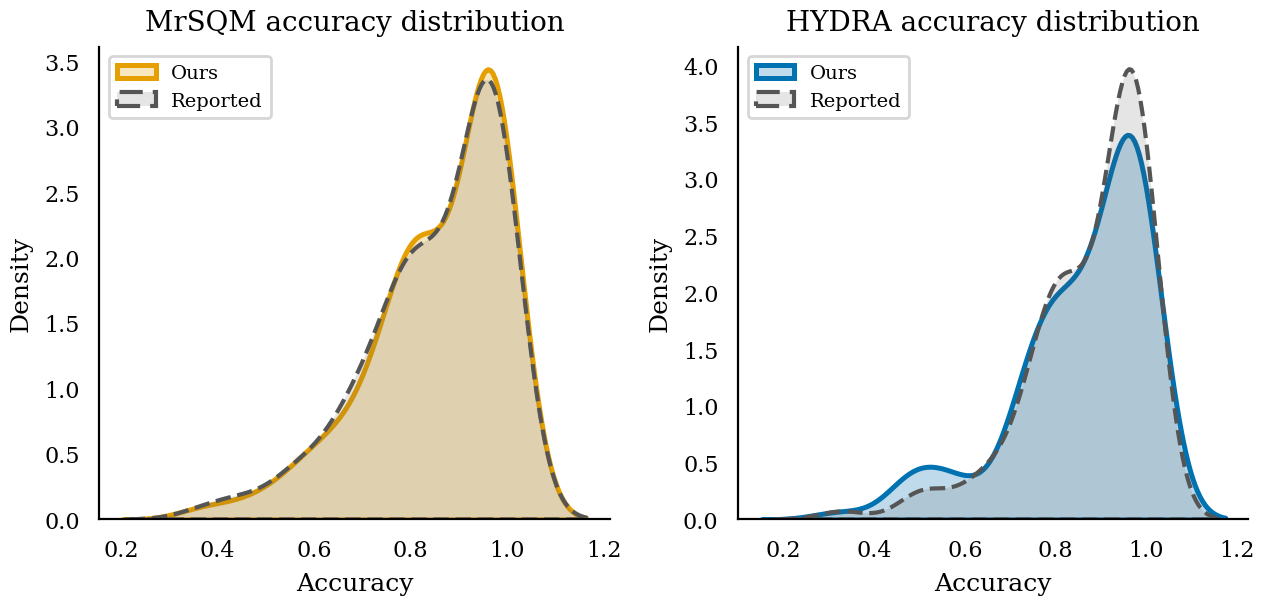

[plot_accuracy_distributions] Saved -> figures/accuracy_distributions.png


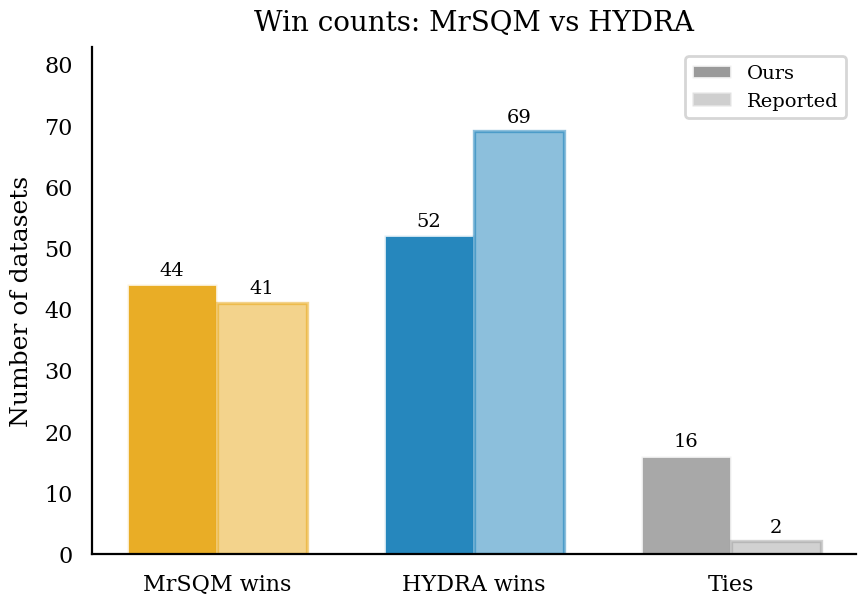

[plot_win_counts] Saved -> figures/win_counts.png


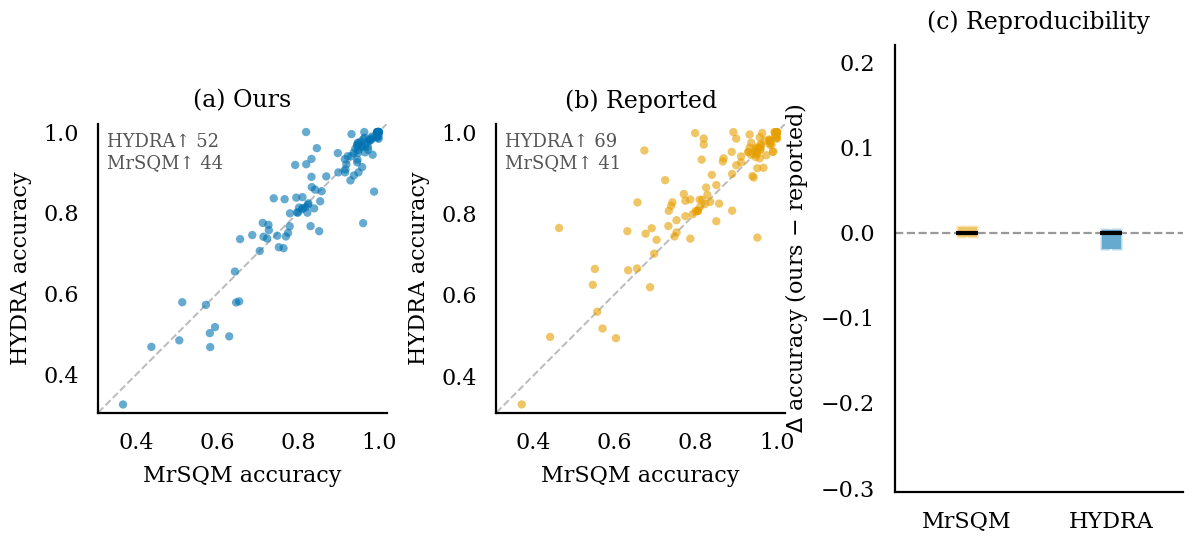

[plot_combined_figure] Saved -> figures/combined_analysis.png

LATEX TABLE — WILCOXON RESULTS
\begin{table}[ht]
\centering
\caption{Wilcoxon Signed-Rank Test Results}
\label{tab:wilcoxon}
\begin{tabular}{llrrcc}
\hline
Test & Hypothesis & $n$ & $W$ & $p$-value & Sig. \\
\hline
(A) H2H — ours & n.s. & 96 & 2196.5 & 0.6308 & n.s. \\
(B) H2H — reported & *** & 110 & 1916.0 & 0.0007 & *** \\
(C) Repro — MrSQM & n.s. & 103 & 2578.0 & 0.7422 & n.s. \\
(D) Repro — HYDRA & * & 107 & 2152.0 & 0.0220 & * \\
\hline
\multicolumn{6}{l}{\footnotesize Significance: *** $p<0.001$, ** $p<0.01$, * $p<0.05$, n.s.\ $p\geq0.05$}
\end{tabular}
\end{table}

LATEX TABLE — SUMMARY STATISTICS
\begin{table}[ht]
\centering
\caption{Summary Statistics Across UCR Datasets}
\label{tab:summary_stats}
\begin{tabular}{lrrrrr}
\hline
Model & Mean & Std & Median & Min & Max \\
\hline
MrSQM (ours) & 0.8556 & 0.1395 & 0.9080 & 0.3660 & 1.0000 \\
HYDRA (ours) & 0.8563 & 0.1488 & 0.9036 & 0.3244 & 1.0000 \\
MrSQM (reported) 

In [115]:
def main():
    print("\n" + "█"*60)
    print("  MrSQM vs HYDRA  —  Full Reproducibility Analysis")
    print("█"*60)

    df = load_data()
    print(f"\nLoaded {len(df)} datasets.")

    # 1. Summary statistics
    summary_df = compute_summary_stats(df)

    # 2. Average ranks
    rank_results = compute_average_ranks(df)

    # 3. Wilcoxon tests
    wilcoxon_df = run_wilcoxon_tests(df)

    # 4–8. Plots
    plot_scatter_my_vs_reported(df)
    plot_diff_bars(df)
    plot_critical_difference(df)
    plot_accuracy_distributions(df)
    plot_win_counts(df)
    plot_combined_figure(df)

    # 9–10. LaTeX tables
    save_latex_snippets(wilcoxon_df, summary_df)

    print("\n" + "="*60)
    print(f"All outputs saved to: ./{OUTPUT_DIR}/")
    print("="*60 + "\n")


if __name__ == "__main__":
    main()